In [61]:
# ============================================================
# SECTION 0: INSTALL DEPENDENCIES
# ============================================================
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score, confusion_matrix
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

In [62]:
# Load the dataset
BASE_PATH = "dataset/"                    # <-- change if needed
TRAIN_X   = BASE_PATH + "UCI HAR Dataset/train/X_train.txt"
TRAIN_Y   = BASE_PATH + "UCI HAR Dataset/train/y_train.txt"
TEST_X    = BASE_PATH + "UCI HAR Dataset/test/X_test.txt"
TEST_Y    = BASE_PATH + "UCI HAR Dataset/test/y_test.txt"

X_train = pd.read_csv(TRAIN_X, sep=r"\s+", header=None)
X_test  = pd.read_csv(TEST_X,  sep=r"\s+", header=None)
y_train = pd.read_csv(TRAIN_Y, sep=r"\s+", header=None).squeeze()
y_test  = pd.read_csv(TEST_Y,  sep=r"\s+", header=None).squeeze()

X_raw = pd.concat([X_train, X_test], ignore_index=True)
y_raw = pd.concat([y_train, y_test], ignore_index=True)

label_map = {1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
            4: "SITTING", 5: "STANDING", 6: "LAYING"}
y_labels = y_raw.map(label_map)
print("Dataset loaded from local files.")

Dataset loaded from local files.


In [63]:
print(f"\nDataset shape  : {X_raw.shape}")
print(f"Activity counts:\n{y_labels.value_counts()}")


Dataset shape  : (10299, 561)
Activity counts:
0
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [64]:
# ============================================================
# SECTION 2: PREPROCESSING
# ============================================================
# 2a. Check missing values
missing = X_raw.isnull().sum().sum()
print(f"Missing values : {missing}  (none expected in this dataset)")
X_clean = X_raw.dropna()
y_clean = y_labels[X_clean.index].reset_index(drop=True)
X_clean = X_clean.reset_index(drop=True)

Missing values : 0  (none expected in this dataset)


In [65]:
# 2b. Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
print(f"Feature matrix after scaling — mean ≈ {X_scaled.mean():.4f}, std ≈ {X_scaled.std():.4f}")

Feature matrix after scaling — mean ≈ -0.0000, std ≈ 1.0000


In [66]:
# 2c. Encode labels as integers (for external metrics)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_int = le.fit_transform(y_clean)

In [67]:
# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS & DIMENSIONALITY REDUCTION
# ============================================================

# 3a. PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum()*100:.2f}%")
 

PCA explained variance (2 components): 56.98%


In [68]:
# 3b. t-SNE to 2D (on PCA-50 for speed)
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_scaled)

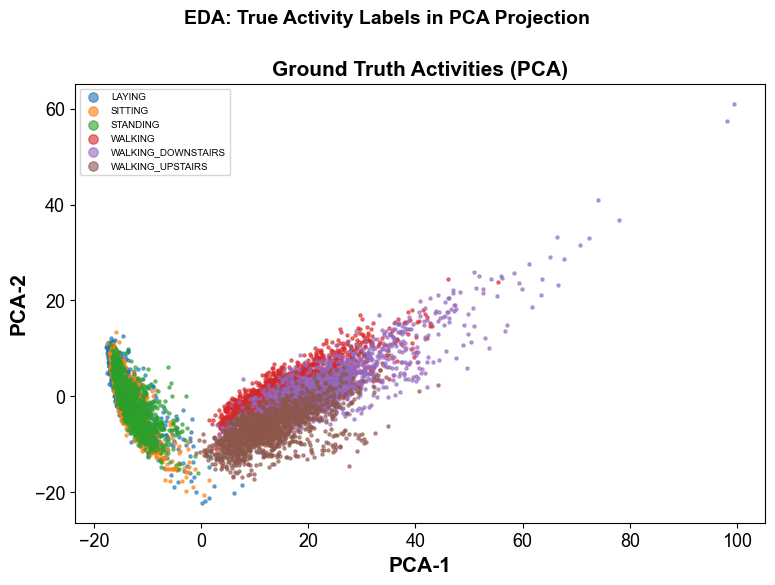

Saved: eda_ground_truth.png


In [69]:
# 3c. Plot ground-truth activities in PCA (single plot)

palette = sns.color_palette("tab10", 6)
activity_palette = dict(zip(le.classes_, palette))

fig, ax = plt.subplots(figsize=(8, 6))

for act in le.classes_:
    mask = y_clean == act
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=5,
        label=act,
        alpha=0.6,
        color=activity_palette[act]
    )

ax.set_title("Ground Truth Activities (PCA)")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.legend(markerscale=3, fontsize=7, loc="best")

plt.suptitle("EDA: True Activity Labels in PCA Projection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_ground_truth.png", dpi=150)
plt.show()

print("Saved: eda_ground_truth.png")

In [70]:
# ============================================================
# SECTION 4: K-MEANS CLUSTERING
# ============================================================

k_range = range(2, 9)
wcss_list      = []
silhouette_list = []
 
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss_list.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=3000, random_state=42)
    silhouette_list.append(sil)
    print(f"  k={k}  WCSS={km.inertia_:.2f}  Silhouette={sil:.4f}")
 
# Print Table 1
print("\nTable 1: K-Means Elbow Method Results")
print(f"{'k':>4}  {'WCSS':>14}  {'Silhouette':>12}")
for k, w, s in zip(k_range, wcss_list, silhouette_list):
    print(f"{k:>4}  {w:>14.2f}  {s:>12.4f}")

  k=2  WCSS=3272856.62  Silhouette=0.3955
  k=3  WCSS=2921077.60  Silhouette=0.3130
  k=4  WCSS=2781602.14  Silhouette=0.1510
  k=5  WCSS=2654789.79  Silhouette=0.1317
  k=6  WCSS=2577180.43  Silhouette=0.1096
  k=7  WCSS=2519774.22  Silhouette=0.0798
  k=8  WCSS=2465378.96  Silhouette=0.0743

Table 1: K-Means Elbow Method Results
   k            WCSS    Silhouette
   2      3272856.62        0.3955
   3      2921077.60        0.3130
   4      2781602.14        0.1510
   5      2654789.79        0.1317
   6      2577180.43        0.1096
   7      2519774.22        0.0798
   8      2465378.96        0.0743


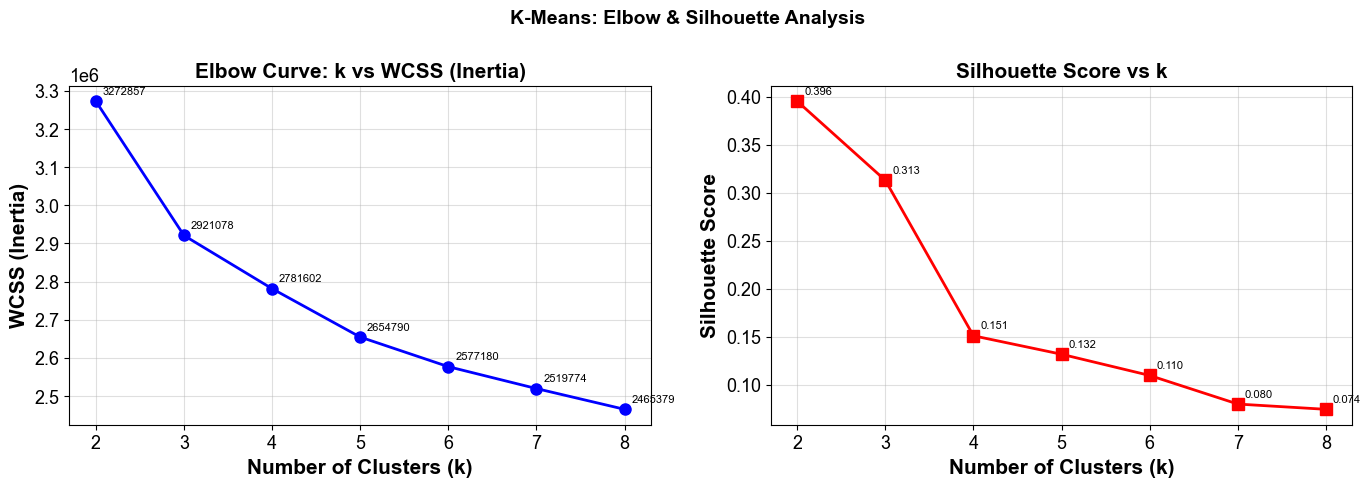

Saved: kmeans_elbow_silhouette.png


In [71]:
# Plot Elbow curve & Silhouette curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(list(k_range), wcss_list, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Curve: k vs WCSS (Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid(True, alpha=0.4)
for k, w in zip(k_range, wcss_list):
    axes[0].annotate(f"{w:.0f}", (k, w), textcoords="offset points", xytext=(5, 5), fontsize=8)
 
axes[1].plot(list(k_range), silhouette_list, "rs-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)
for k, s in zip(k_range, silhouette_list):
    axes[1].annotate(f"{s:.3f}", (k, s), textcoords="offset points", xytext=(5, 5), fontsize=8)
 
plt.suptitle("K-Means: Elbow & Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=150)
plt.show()
print("Saved: kmeans_elbow_silhouette.png")

In [72]:
# Best k = 6 (matches number of activities; elbow typically near 6)
BEST_K = 3
print(f"\nSelected k = {BEST_K} (matches number of activities; confirmed by Elbow/Silhouette)")
 
km_best = KMeans(n_clusters=BEST_K, init="k-means++", n_init=20, random_state=42)
km_best.fit(X_scaled)
km_labels = km_best.labels_


Selected k = 3 (matches number of activities; confirmed by Elbow/Silhouette)


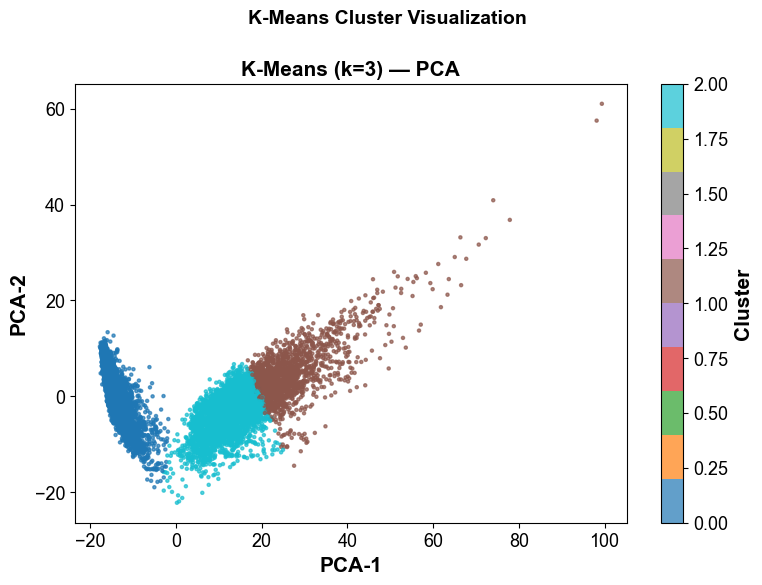

Saved: kmeans_clusters.png


In [73]:
# Visualize K-Means clusters (PCA only)
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=km_labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)

ax.set_title(f"K-Means (k={BEST_K}) — PCA")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")

plt.colorbar(scatter, ax=ax, label="Cluster")

plt.suptitle("K-Means Cluster Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

print("Saved: kmeans_clusters.png")

In [74]:
# ============================================================
# SECTION 5: DBSCAN CLUSTERING
# ============================================================

# Use PCA-50 representation for DBSCAN
pca_dbscan = PCA(n_components=50, random_state=42)
X_db = pca_dbscan.fit_transform(X_scaled)

print("After PCA:", X_db.shape)

# Hyperparameter tuning
eps_values = [2, 3, 4, 5, 6, 8, 10]
minPts = 10

print("\nDBSCAN Tuning Results")
print(f"{'eps':>5} {'clusters':>10} {'noise':>10} {'silhouette':>12}")


After PCA: (10299, 50)

DBSCAN Tuning Results
  eps   clusters      noise   silhouette


In [75]:
best_db = None
best_eps = None
best_sil = -1

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=minPts, n_jobs=-1)
    db.fit(X_db)

    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    sil = -1

    # Compute silhouette only if valid clusters exist
    if n_clusters >= 2:
        mask = labels != -1
        if mask.sum() > 2:
            try:
                sil = silhouette_score(X_db[mask], labels[mask])
            except:
                sil = -1

    print(f"{eps:>5} {n_clusters:>10} {n_noise:>10} {sil:>12.4f}")

    if sil > best_sil and n_clusters >= 2:
        best_sil = sil
        best_db = db
        best_eps = eps

    2          0      10299      -1.0000
    3          0      10299      -1.0000
    4          0      10299      -1.0000
    5          0      10299      -1.0000
    6          6       9132       0.1541
    8         12       5746       0.1252
   10          9       3327       0.3792


In [76]:
print(f"\nBest DBSCAN: eps = {best_eps}, minPts = {minPts}")

db_labels = best_db.labels_

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} ({100*n_noise/len(db_labels):.2f}%)")


Best DBSCAN: eps = 10, minPts = 10
Clusters found : 9
Noise points   : 3327 (32.30%)


In [77]:
mask = db_labels != -1  # remove noise for internal metrics

if len(set(db_labels[mask])) > 1:
    sil_score = silhouette_score(X_db[mask], db_labels[mask])
    db_index = davies_bouldin_score(X_db[mask], db_labels[mask])
    ch_score = calinski_harabasz_score(X_db[mask], db_labels[mask])
else:
    sil_score, db_index, ch_score = -1, -1, -1

# External metrics (compare with ground truth)
ari = adjusted_rand_score(y_int, db_labels)
nmi = normalized_mutual_info_score(y_int, db_labels)

print("\nEvaluation Metrics:")
print(f"Silhouette Score        : {sil_score:.4f}")
print(f"Davies-Bouldin Index   : {db_index:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")
print(f"Adjusted Rand Index    : {ari:.4f}")
print(f"Normalized Mutual Info : {nmi:.4f}")



Evaluation Metrics:
Silhouette Score        : 0.3792
Davies-Bouldin Index   : 1.4376
Calinski-Harabasz Score: 909.8693
Adjusted Rand Index    : 0.2843
Normalized Mutual Info : 0.4360


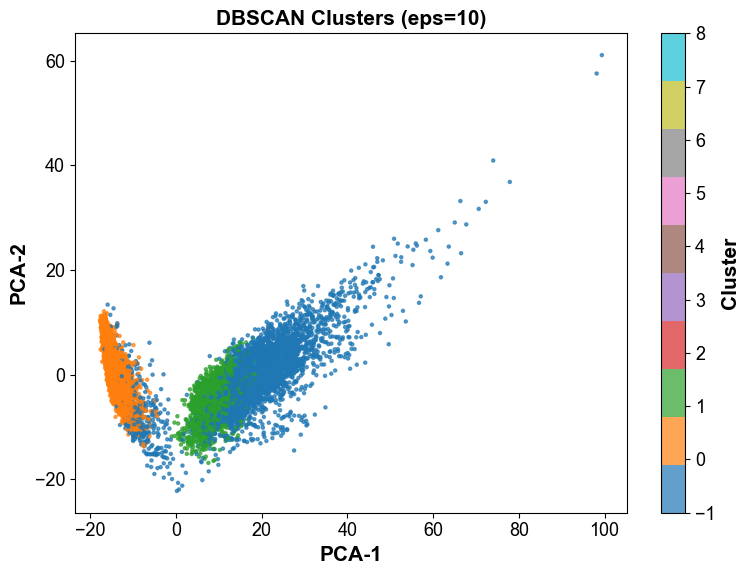

Saved: dbscan_clusters.png


In [78]:
# Visualise
pca_2d = PCA(n_components=2, random_state=42)
X_vis = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=db_labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.title(f"DBSCAN Clusters (eps={best_eps})")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")

plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("dbscan_clusters.png", dpi=150)
plt.show()

print("Saved: dbscan_clusters.png")

In [79]:
# SECTION 6: HIERARCHICAL AGGLOMERATIVE CLUSTERING

# Use PCA-50 for hierarchy computation (speed)
pca_hac = PCA(n_components=50, random_state=42)
X_hac = pca_hac.fit_transform(X_scaled)

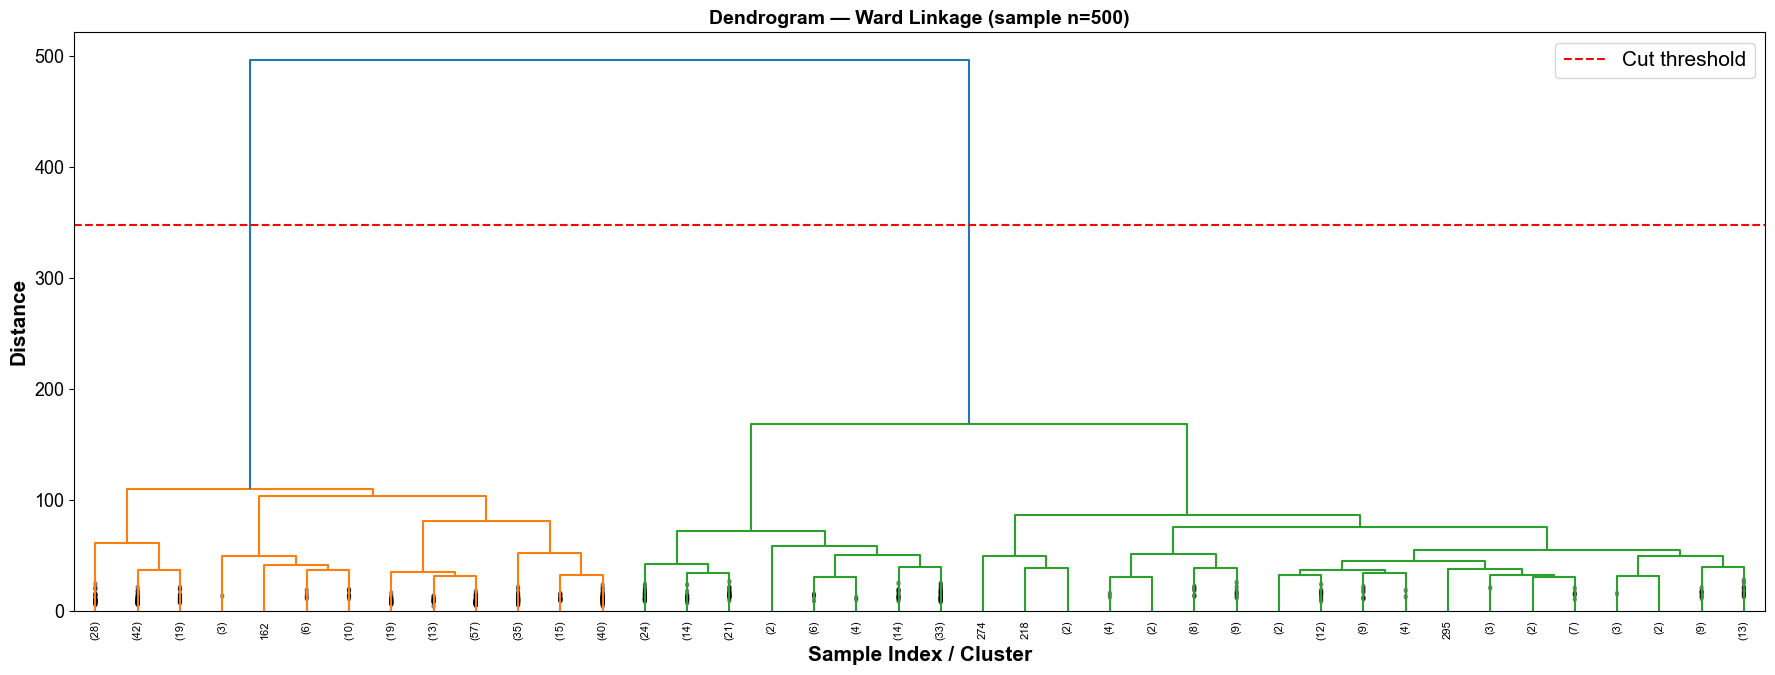

Saved: hac_dendrogram.png


In [80]:
# 6a. Dendrogram (on sample for visibility)
sample_idx = np.random.choice(len(X_hac), 500, replace=False)
X_sample   = X_hac[sample_idx]
Z = linkage(X_sample, method="ward")
 
fig, ax = plt.subplots(figsize=(18, 7))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=40,
           leaf_rotation=90, leaf_font_size=8,
           show_contracted=True, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Dendrogram — Ward Linkage (sample n=500)", fontsize=14, fontweight="bold")
ax.set_xlabel("Sample Index / Cluster")
ax.set_ylabel("Distance")
ax.axhline(y=0.7 * max(Z[:, 2]), color="red", linestyle="--", label="Cut threshold")
ax.legend()
plt.tight_layout()
plt.savefig("hac_dendrogram.png", dpi=150)
plt.show()
print("Saved: hac_dendrogram.png")

In [81]:
# 6b. Compare linkage methods
print("\nLinkage Comparison (n_clusters=6):")
print(f"{'Linkage':>12}  {'Silhouette':>12}  {'DB Index':>10}  {'CH Index':>12}")
 
linkage_results = {}
for method in ["ward", "complete", "average", "single"]:
    hac = AgglomerativeClustering(n_clusters=6, linkage=method)
    hac_lbl = hac.fit_predict(X_hac)
    sil = silhouette_score(X_hac, hac_lbl, sample_size=3000, random_state=42)
    db  = davies_bouldin_score(X_hac, hac_lbl)
    ch  = calinski_harabasz_score(X_hac, hac_lbl)
    linkage_results[method] = {"labels": hac_lbl, "sil": sil, "db": db, "ch": ch}
    print(f"{method:>12}  {sil:>12.4f}  {db:>10.4f}  {ch:>12.2f}")
 
# Best linkage = Ward
hac_labels = linkage_results["ward"]["labels"]


Linkage Comparison (n_clusters=6):
     Linkage    Silhouette    DB Index      CH Index
        ward        0.1293      2.0645       3292.69
    complete        0.2533      1.3616       1123.89
     average        0.4031      0.9724        211.94
      single        0.8048      0.2335         32.35


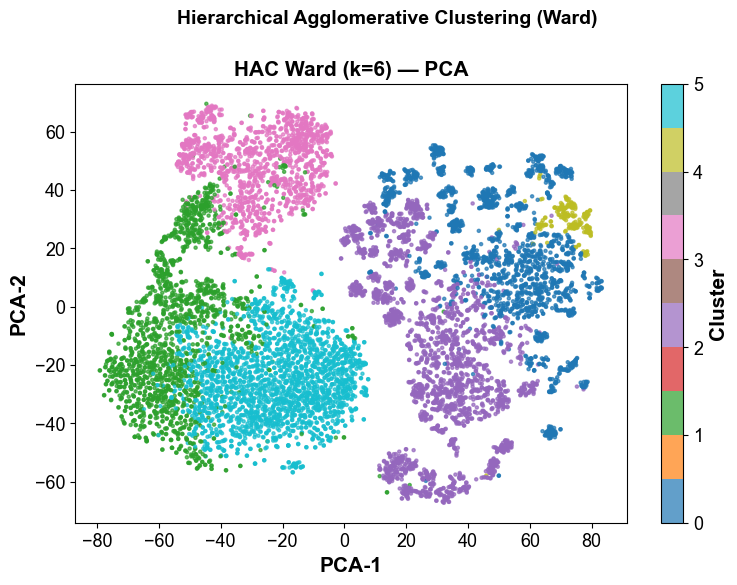

Saved: hac_clusters.png


In [82]:
# Visualize HAC (Ward) — Single Plot (PCA)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=hac_labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)

ax.set_title("HAC Ward (k=6) — PCA")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")

plt.colorbar(scatter, ax=ax, label="Cluster")

plt.suptitle("Hierarchical Agglomerative Clustering (Ward)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("hac_clusters.png", dpi=150)
plt.show()

print("Saved: hac_clusters.png")

In [83]:
# SECTION 7: EVALUATION METRICS

# Remove noise points from DBSCAN before external metrics
db_mask  = db_labels != -1
db_int   = db_labels[db_mask]
y_int_db = y_int[db_mask]
 
results = {}

for name, labels, y_true in [
    ("K-Means",       km_labels,   y_int),
    ("DBSCAN",        db_int,      y_int_db),
    ("HAC (Ward)",    hac_labels,  y_int),
]:
    sil = silhouette_score(X_scaled[:len(labels)] if name != "DBSCAN" else X_db[db_mask],
                           labels, sample_size=3000, random_state=42)
    dbi = davies_bouldin_score(X_scaled[:len(labels)] if name != "DBSCAN" else X_db[db_mask], labels)
    chi = calinski_harabasz_score(X_scaled[:len(labels)] if name != "DBSCAN" else X_db[db_mask], labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    results[name] = {"Silhouette": sil, "DB Index": dbi, "CH Index": chi, "ARI": ari, "NMI": nmi}


print(f"\n{'Algorithm':<15} {'Silhouette':>12} {'DB Index':>10} {'CH Index':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 70)
for algo, m in results.items():
    print(f"{algo:<15} {m['Silhouette']:>12.4f} {m['DB Index']:>10.4f} "
          f"{m['CH Index']:>12.2f} {m['ARI']:>8.4f} {m['NMI']:>8.4f}")


Algorithm         Silhouette   DB Index     CH Index      ARI      NMI
----------------------------------------------------------------------
K-Means               0.3130     1.7865      5034.48   0.3317   0.5183
DBSCAN                0.3730     1.4376       909.87   0.2811   0.5132
HAC (Ward)            0.0929     2.4850      2380.80   0.4218   0.5792


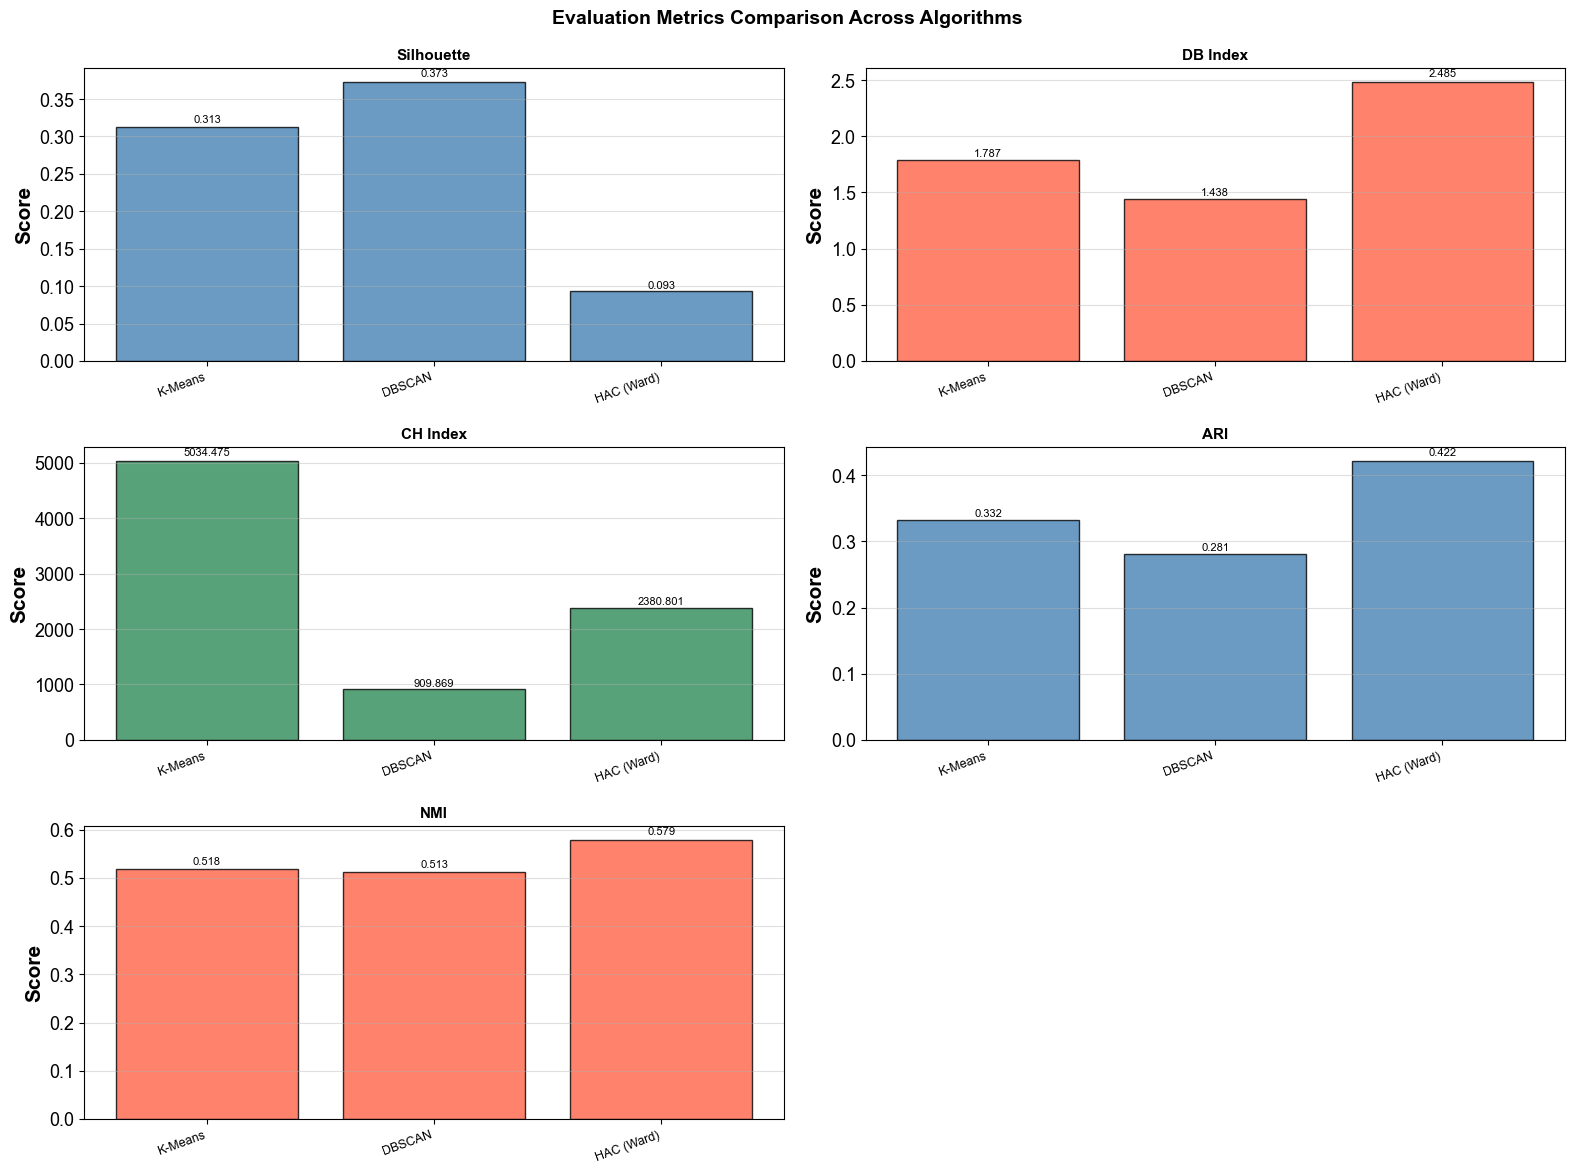

Saved: metrics_comparison.png


In [84]:
# Bar plots of metrics

metrics_df = pd.DataFrame(results).T

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()  # IMPORTANT

metrics = ["Silhouette", "DB Index", "CH Index", "ARI", "NMI"]
colors = ["steelblue", "tomato", "seagreen"]

for i, metric in enumerate(metrics):
    ax = axes[i]

    ax.bar(
        metrics_df.index,
        metrics_df[metric],
        color=colors[i % len(colors)],
        edgecolor="black",
        alpha=0.8
    )

    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xticklabels(metrics_df.index, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.4)

    # value labels
    for j, (idx, val) in enumerate(zip(metrics_df.index, metrics_df[metric])):
        ax.text(j, val + 0.01 * abs(val), f"{val:.3f}",
                ha="center", va="bottom", fontsize=8)

# Hide the last empty subplot
axes[-1].axis("off")

plt.suptitle("Evaluation Metrics Comparison Across Algorithms",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()

print("Saved: metrics_comparison.png")

In [85]:
# SECTION 8: CONFUSION MATRIX (K-Means vs Ground Truth)

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def map_clusters_to_labels(true_labels, pred_labels):
    """Map cluster IDs to true labels using Hungarian algorithm"""

    true_classes = np.unique(true_labels)
    clusters = np.unique(pred_labels)

    n_true = len(true_classes)
    n_clusters = len(clusters)

    # Correct size: (true classes × clusters)
    cost_matrix = np.zeros((n_true, n_clusters), dtype=int)

    for t, p in zip(true_labels, pred_labels):
        cost_matrix[t, p] += 1

    # Hungarian algorithm (maximize → use negative)
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)

    # Create mapping: cluster → label
    mapping = {col: row for row, col in zip(row_ind, col_ind)}

    # Map predictions
    mapped = np.array([mapping.get(p, -1) for p in pred_labels])

    return mapped


# Apply mapping
km_mapped = map_clusters_to_labels(y_int, km_labels)

# Confusion matrix
cm = confusion_matrix(y_int, km_mapped)

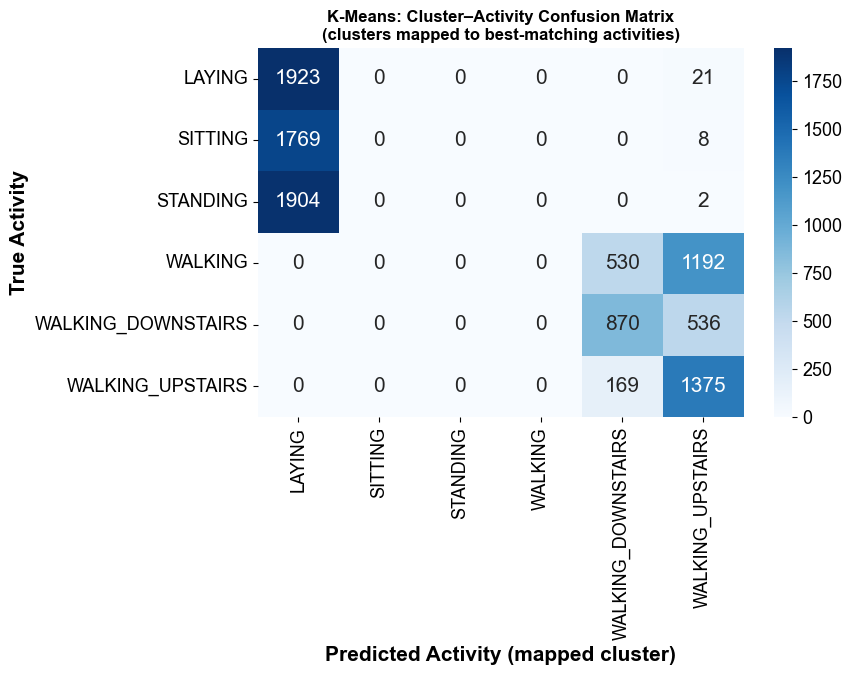

Saved: kmeans_confusion_matrix.png


In [86]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title("K-Means: Cluster–Activity Confusion Matrix\n(clusters mapped to best-matching activities)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Activity (mapped cluster)")
ax.set_ylabel("True Activity")
plt.tight_layout()
plt.savefig("kmeans_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: kmeans_confusion_matrix.png")

In [87]:
# SECTION 9: FINAL SUMMARY
best_sil = max(results, key=lambda x: results[x]["Silhouette"])
best_ari = max(results, key=lambda x: results[x]["ARI"])
best_nmi = max(results, key=lambda x: results[x]["NMI"])
best_dbi = min(results, key=lambda x: results[x]["DB Index"])

In [88]:
print(f"""
Observations:
─────────────────────────────────────────────────────────────
1. Best Silhouette Score : {best_sil}  ({results[best_sil]['Silhouette']:.4f})
   → Produces most cohesive and well-separated clusters.
 
2. Best ARI (vs ground truth): {best_ari}  ({results[best_ari]['ARI']:.4f})
   → Cluster assignments closest to true activity labels.
 
3. Best NMI                  : {best_nmi}  ({results[best_nmi]['NMI']:.4f})
   → Highest mutual information with true labels.
 
4. Best Davies–Bouldin Index : {best_dbi}  ({results[best_dbi]['DB Index']:.4f})
   → Lowest intra/inter cluster distance ratio (lower = better).
 
""")


Observations:
─────────────────────────────────────────────────────────────
1. Best Silhouette Score : DBSCAN  (0.3730)
   → Produces most cohesive and well-separated clusters.

2. Best ARI (vs ground truth): HAC (Ward)  (0.4218)
   → Cluster assignments closest to true activity labels.

3. Best NMI                  : HAC (Ward)  (0.5792)
   → Highest mutual information with true labels.

4. Best Davies–Bouldin Index : DBSCAN  (1.4376)
   → Lowest intra/inter cluster distance ratio (lower = better).


